In [17]:
import torch
import numpy as np
import matplotlib.pyplot as plt
# use retina mode
%config InlineBackend.figure_format = 'retina'

In [189]:
def mean_abs_offdiag_cosine(W, eps=0):
    W = np.asarray(W)
    W_norm = W / (np.linalg.norm(W, axis=1, keepdims=True) + eps)
    C = W_norm @ W_norm.T

    m = W.shape[0]
    offdiag = C[~np.eye(m, dtype=bool)]
    return np.mean(np.abs(offdiag)), C

def row_energy_imbalance(W, eps=0):
    W = np.asarray(W)
    e = np.sum(W ** 2, axis=1)
    p = e / (e.sum() + eps)

    participation_ratio = 1.0 / (np.sum(p ** 2) + eps)
    imbalance = len(p) / (participation_ratio + eps)

    return {
        "row_energy": e,
        "energy_probs": p,
        "effective_num_rows": participation_ratio,
        "energy_imbalance": imbalance,
    }

In [273]:
ckpt_dir = '/home/xwang457/work/nanomoe/pretrain_log_with_ckpt/data-finewebedu_seed-42_opt-adamw_lr-0p001_wd-0p01_steps-2000_ga-48_warmup-100_hm-100_depth-1/checkpoints/latest/checkpoint.pt'
# load the checkpoint
checkpoint_adamw = torch.load(ckpt_dir, map_location='cuda', weights_only=False)

ckpt_dir = '/home/xwang457/work/nanomoe/pretrain_log_with_ckpt/data-finewebedu_seed-42_opt-muon_lr-0p001_wd-0p01_steps-2000_ga-48_warmup-100_hm-100_depth-1/checkpoints/latest/checkpoint.pt'
# load the checkpoint
checkpoint_muon = torch.load(ckpt_dir, map_location='cuda', weights_only=False)

In [266]:
cvs = []
row_correlation = []

for layer_id in np.arange(12):
    P_adamw = checkpoint_adamw['model'][
        f'layers.{layer_id}.mlp.router.gate.weight'
    ].cpu().float().numpy()
    # covs_adamw.append(P_adamw)

    P_muon = checkpoint_muon['model'][
        f'layers.{layer_id}.mlp.router.gate.weight'
    ].cpu().float().numpy()
    # covs_muon.append(P_muon)
    cvs.append((
        row_energy_imbalance(P_adamw)['energy_imbalance'],
        row_energy_imbalance(P_muon)['energy_imbalance']
    ))
    row_correlation.append((
        mean_abs_offdiag_cosine(P_adamw)[0],
        mean_abs_offdiag_cosine(P_muon)[0]
    ))

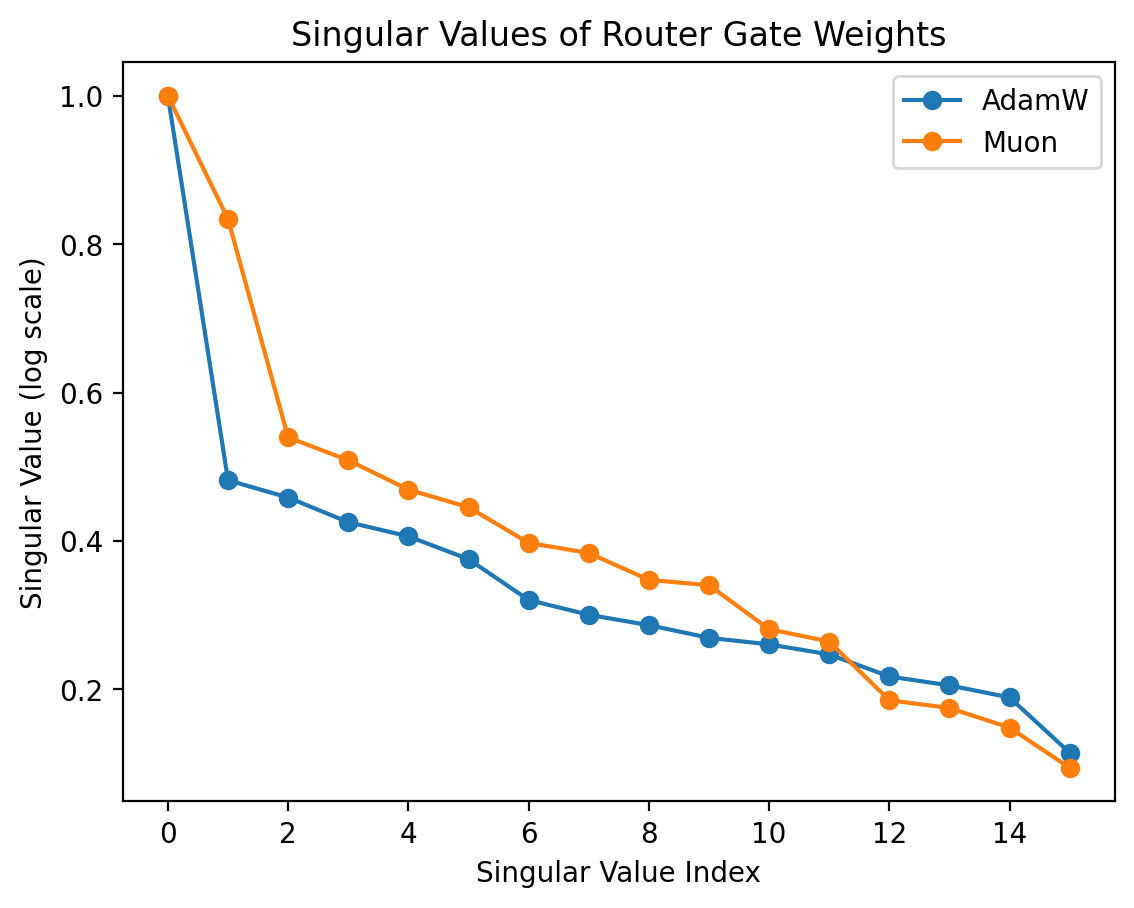

In [267]:
# plt.imshow(np.cov(P_muon))
# plt.colorbar()
# plt.title('Covariance Matrix of P_muon')
layer_id = 11
P_adamw = checkpoint_adamw['model'][
    f'layers.{layer_id}.mlp.router.gate.weight'
].cpu().float().numpy()
P_muon = checkpoint_muon['model'][
    f'layers.{layer_id}.mlp.router.gate.weight'
].cpu().float().numpy()
svs = np.linalg.svd(P_adamw, compute_uv=False)
# normalize for better visualization
svs = svs / (svs[0] + 1e-12)
plt.plot(svs, label='AdamW', marker='o')
svs = np.linalg.svd(P_muon, compute_uv=False)
# normalize for better visualization
svs = svs / (svs[0] + 1e-12)
plt.plot(svs, label='Muon', marker='o')
# plt.yscale('log')
plt.xlabel('Singular Value Index')
plt.ylabel('Singular Value (log scale)')
plt.title('Singular Values of Router Gate Weights')
plt.legend()
plt.show()

Text(0.5, 0, 'Layer ID')

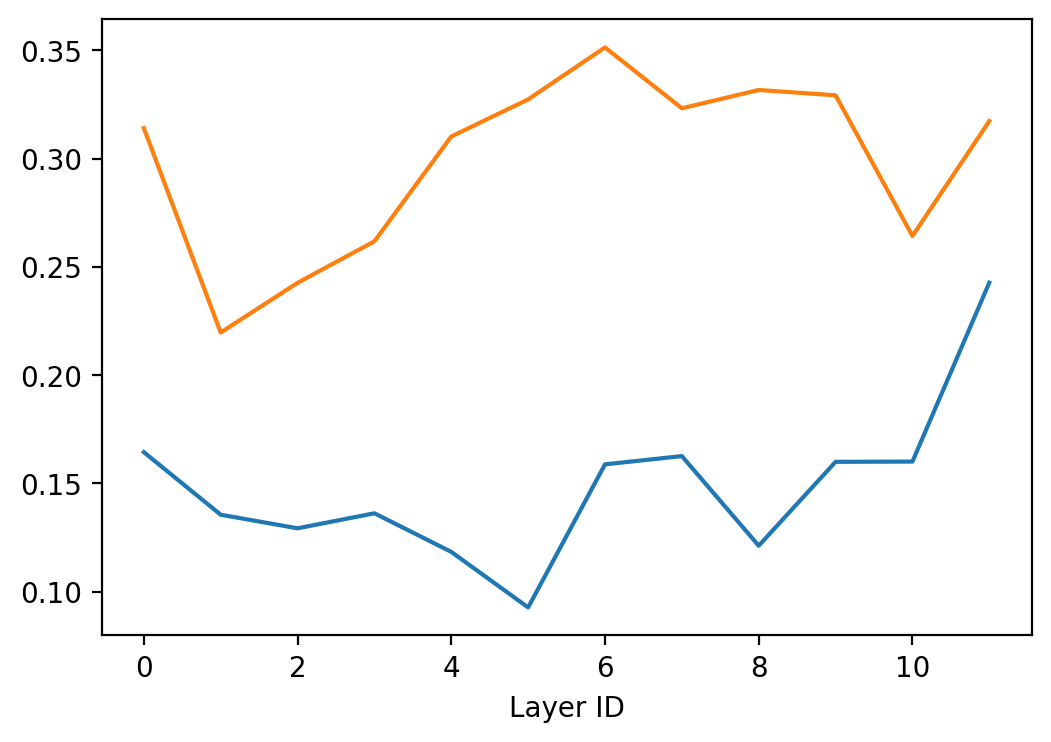

In [268]:
plt.figure(figsize=(6, 4))
plt.plot(np.arange(12), [cv[0] for cv in row_correlation], label='AdamW')
plt.plot(np.arange(12), [cv[1] for cv in row_correlation], label='Muon')
plt.xlabel('Layer ID')

Text(0.5, 0, 'Layer ID')

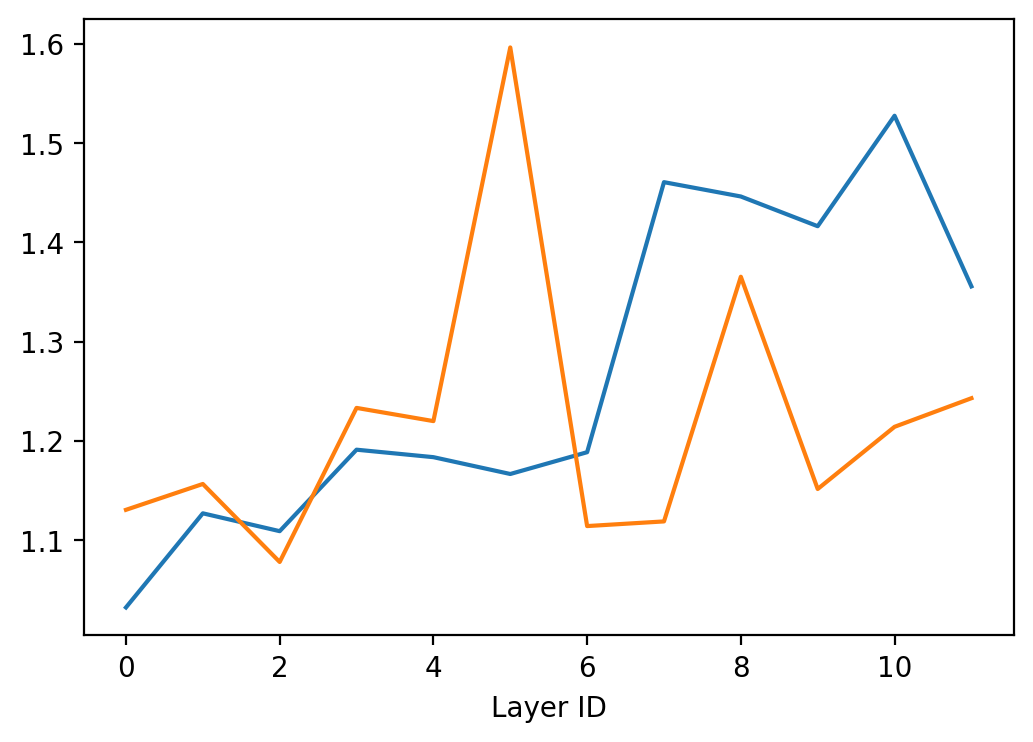

In [269]:
plt.figure(figsize=(6, 4))
plt.plot(np.arange(12), [cv[0] for cv in cvs], label='AdamW')
plt.plot(np.arange(12), [cv[1] for cv in cvs], label='Muon')
plt.xlabel('Layer ID')

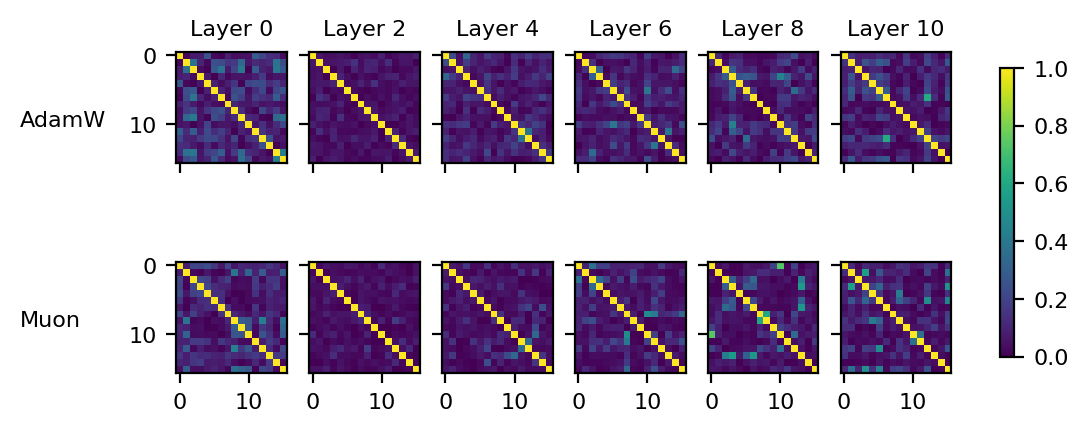

In [275]:
layer_ids = [0, 2, 4, 6, 8, 10]

# First compute all correlation matrices
covs_adamw = []
covs_muon = []

for layer_id in layer_ids:
    P_adamw = checkpoint_adamw['model'][
        f'layers.{layer_id}.mlp.router.gate.weight'
    ].cpu().float().numpy()
    covs_adamw.append(np.corrcoef(P_adamw))

    P_muon = checkpoint_muon['model'][
        f'layers.{layer_id}.mlp.router.gate.weight'
    ].cpu().float().numpy()
    covs_muon.append(np.corrcoef(P_muon))

# Shared color scale
vmin = 0
vmax = 1

fig, axes = plt.subplots(
    2, len(layer_ids),
    figsize=(6.25, 2.5),
    sharex=True,
    sharey=True
)

for i, layer_id in enumerate(layer_ids):
    im = axes[0, i].imshow(
        np.abs(covs_adamw[i]),
        vmin=vmin,
        vmax=vmax,
        # cmap="coolwarm"
    )
    axes[0, i].set_title(f'Layer {layer_id}', fontsize=8)

    axes[1, i].imshow(
        np.abs(covs_muon[i]),
        vmin=vmin,
        vmax=vmax,
        # cmap="coolwarm"
    )

    # Optional: remove ticks for cleaner layout
    axes[0, i].tick_params(labelsize=8)
    axes[1, i].tick_params(labelsize=8)

# Row labels on the left
fig.text(0.0, 0.68, "AdamW", va="center", ha="left", fontsize=8, rotation=0)
fig.text(0.0, 0.28, "Muon",  va="center", ha="left", fontsize=8, rotation=0)

# Shared colorbar
cbar = fig.colorbar(im, ax=axes, shrink=0.75)
cbar.ax.tick_params(labelsize=8)

# plt.tight_layout(rect=[0.05, 0, 1, 1])
plt.show()

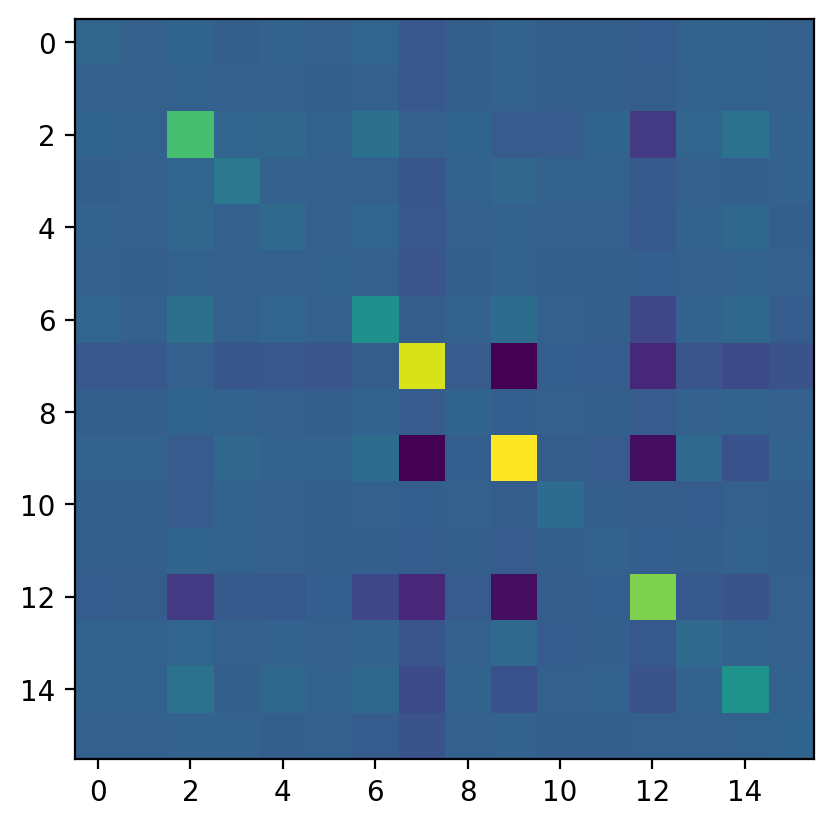

In [76]:
P = checkpoint['model']['layers.2.mlp.router.gate.weight'].cpu().float().numpy()
# compute the covariance matrix
cov = np.cov(P)
plt.imshow(cov)